In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


In [7]:
import pandas as pd

data = pd.read_csv('bank.csv', sep=';')  # Essayez aussi ',' ou '\t' si besoin
data


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


In [9]:
data.dropna(inplace=True)

In [21]:
print(data.columns)


Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')


In [10]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [11]:
X = data.drop(columns=['y'])  # Features
y = LabelEncoder().fit_transform(data['y'])  

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] 

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8961325966850828
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94       807
           1       0.56      0.20      0.30        98

    accuracy                           0.90       905
   macro avg       0.73      0.59      0.62       905
weighted avg       0.87      0.90      0.87       905



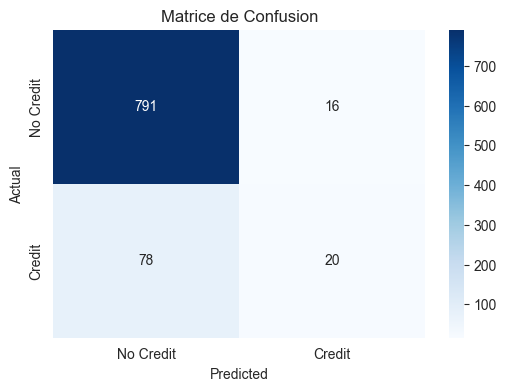

In [17]:
plt.figure(figsize=(6,4))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['No Credit', 'Credit'], yticklabels=['No Credit', 'Credit'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matrice de Confusion")
plt.show()

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

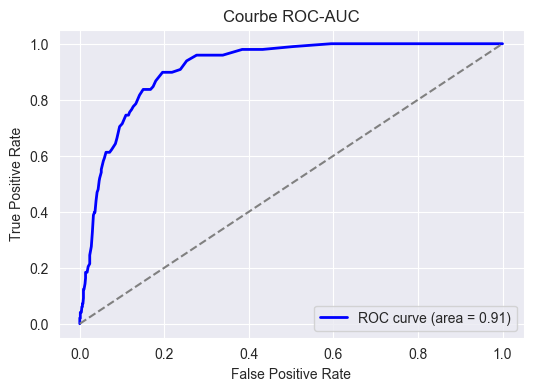

In [19]:
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC-AUC")
plt.legend(loc="lower right")
plt.show()

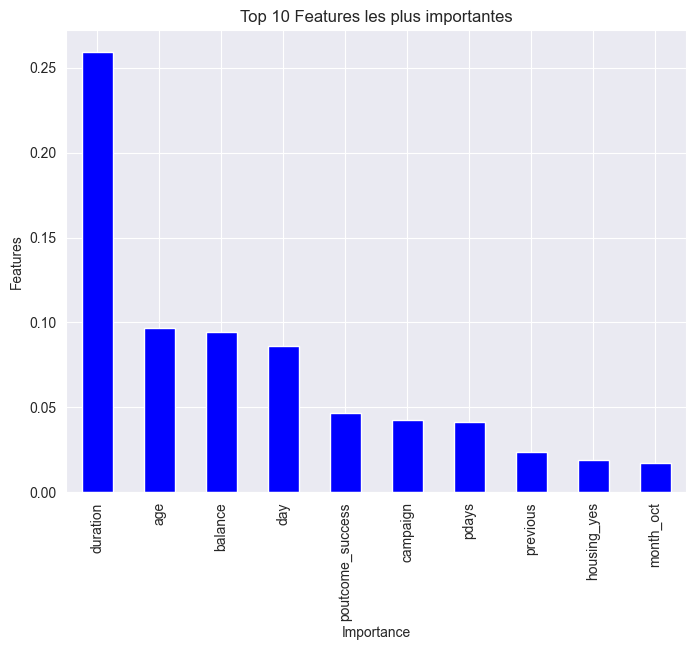

In [20]:
plt.figure(figsize=(8,6))
feature_importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
feature_importance[:10].plot(kind='bar', color='blue')
plt.title("Top 10 Features les plus importantes")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

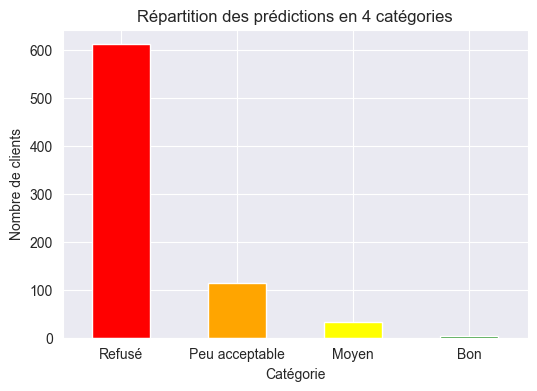

In [22]:
# Création des catégories en fonction des probabilités de prédiction
categories = pd.cut(y_prob, bins=[0, 0.25, 0.5, 0.75, 1], labels=['Refusé', 'Peu acceptable', 'Moyen', 'Bon'])

# Comptage des occurrences dans chaque catégorie
category_counts = categories.value_counts().sort_index()

# Tracé du graphique
plt.figure(figsize=(6, 4))
category_counts.plot(kind='bar', color=['red', 'orange', 'yellow', 'green'])
plt.xlabel("Catégorie")
plt.ylabel("Nombre de clients")
plt.title("Répartition des prédictions en 4 catégories")
plt.xticks(rotation=0)
plt.show()

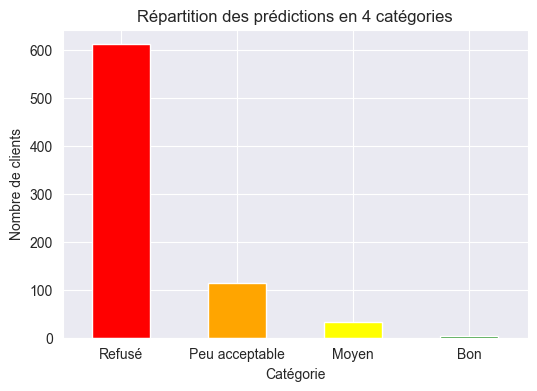

In [23]:
# Création des catégories en fonction des probabilités de prédiction
categories = pd.cut(y_prob, bins=[0, 0.25, 0.5, 0.75, 1], labels=['Refusé', 'Peu acceptable', 'Moyen', 'Bon'])

# Comptage des occurrences dans chaque catégorie
category_counts = categories.value_counts().sort_index()

# Tracé du graphique
plt.figure(figsize=(6, 4))
category_counts.plot(kind='bar', color=['red', 'orange', 'yellow', 'green'])
plt.xlabel("Catégorie")
plt.ylabel("Nombre de clients")
plt.title("Répartition des prédictions en 4 catégories")
plt.xticks(rotation=0)
plt.show()

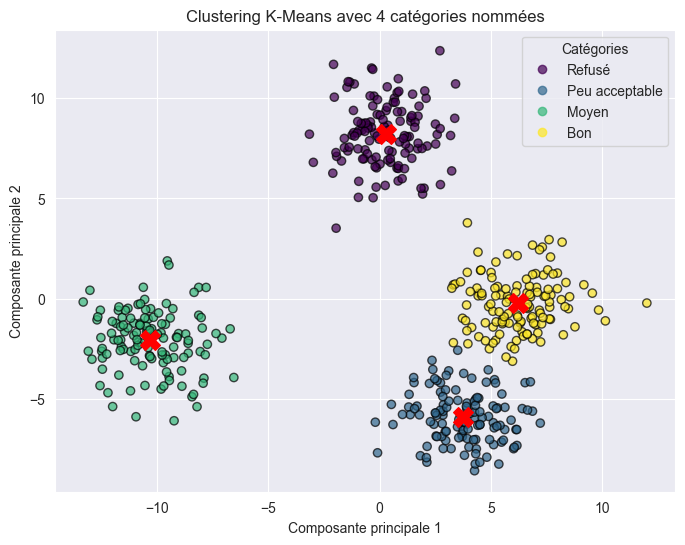

In [25]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Génération de données synthétiques pour le clustering
# Définition des noms des catégories
category_labels = {0: "Refusé", 1: "Peu acceptable", 2: "Moyen", 3: "Bon"}

# Attribution des noms aux clusters identifiés par K-Means
cluster_names = [category_labels[label] for label in y_kmeans]

# Tracé des points avec les nouvelles catégories nommées
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', edgecolor='k', alpha=0.7)

# Ajout des centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label="Centroids")

# Légende pour les clusters
handles, _ = scatter.legend_elements()
legend_labels = [category_labels[i] for i in range(4)]
plt.legend(handles, legend_labels, title="Catégories")

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Clustering K-Means avec 4 catégories nommées")
plt.show()